In [23]:
from google import genai
import os

client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-3.6-flash
models/gemini-3.7-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.6-preview
models/gemini-robotics-er-2-preview
models/gemini-2.5-computer-use-p

In [24]:
import sys
print(sys.executable)

e:\projects\blog-writing-agent-main\blog-writing-agent-main\venv\Scripts\python.exe


In [25]:
import sys
!{sys.executable} -m pip install -U langchain-google-genai


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import sys

print(sys.executable)

from langchain_google_genai import ChatGoogleGenerativeAI

print("Gemini package working!")

e:\projects\blog-writing-agent-main\blog-writing-agent-main\venv\Scripts\python.exe
Gemini package working!


In [27]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage

from dotenv import load_dotenv
load_dotenv()

True

In [28]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [29]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [30]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [40]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0.7,
)

In [41]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [42]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [43]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    response = llm.invoke(
        [
            SystemMessage(
                content="Write one clean Markdown section."
            ),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    )

    # Gemini can return content as either a string or a list
    if isinstance(response.content, list):

        section_md = "".join(
            block.get("text", "")
            if isinstance(block, dict)
            else str(block)
            for block in response.content
        ).strip()

    else:
        section_md = str(response.content).strip()

    return {"sections": [section_md]}

In [44]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}


In [45]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

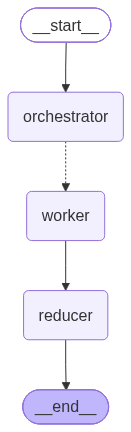

In [46]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [47]:
from IPython.display import display, Markdown

out = app.invoke({
    "topic": "Write a blog on Self Attention",
    "sections": []
})

display(Markdown(out["final"]))

e:\projects\blog-writing-agent-main\blog-writing-agent-main\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
e:\projects\blog-writing-agent-main\blog-writing-agent-main\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
e:\projects\blog-writing-agent-main\blog-writing-agent-main\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
e:\projects\blog-writing-agent-main\blog-writing-agent-main\venv\Lib\site-packages\langchain_google_genai\chat_mode

# Demystifying Self-Attention: The Core Engine of Modern AI

## Introduction to Self-Attention

At the heart of the modern artificial intelligence boom lies a deceptively simple yet revolutionary mechanism: **self-attention**. To understand why today's AI models—from ChatGPT to advanced image generators—can understand context, nuance, and complex relationships in data, you must first understand this core engine. 

### What is Self-Attention?

In human language, the meaning of a word depends entirely on its context. Consider the word "bank." In the sentence, *"I sat by the river bank,"* it means the edge of a river. In *"I deposited money in the bank,"* it refers to a financial institution. 

Before self-attention, traditional neural networks struggled with this fluidity. They processed data sequentially (like reading word-by-word), often forgetting the beginning of a long sentence by the time they reached the end. 

Self-attention changes the game. It is a mathematical mechanism that allows a model to weigh the importance of different words in a sentence relative to one another, **regardless of their distance apart**. When processing a specific word, self-attention looks at the entire input sequence simultaneously and asks: *"Which other words are most relevant to understanding this one?"* 

### The Revolution in Deep Learning

Self-attention revolutionized deep learning by solving the two biggest bottlenecks of older architectures (like Recurrent Neural Networks and LSTMs):

1. **Parallelization:** Older models had to process data one step at a time, making it impossible to train them on massive datasets using modern GPUs. Self-attention processes all words simultaneously, slashing training times from weeks to hours and enabling the training of giant models.
2. **Long-Range Context:** By directly connecting every word to every other word, self-attention creates a web of contextual relationships. It easily bridges gaps across paragraphs to resolve pronouns, detect sarcasm, and maintain coherent narratives.

### The Engine of the Transformer

Self-attention is the beating heart of the **Transformer architecture**, introduced by Google researchers in their landmark 2017 paper, *"Attention Is All You Need."* By replacing older recurrent layers with layers of self-attention, Transformers unlocked unprecedented scaling capabilities. 

Today, self-attention forms the foundational building block of virtually every state-of-the-art Large Language Model (LLM). By breaking down how machines weigh information dynamically, we can begin to demystify how AI achieves its uncanny, human-like grasp of language.

## The Limitations of Traditional Architectures

Before self-attention revolutionized the AI landscape, sequence modeling was dominated by Recurrent Neural Networks (RNNs) and their more sophisticated variant, Long Short-Term Memory networks (LSTMs). To understand why self-attention became the core engine of modern AI, we first need to look at how these older architectures handled sequential data—and where they ultimately fell short.

RNNs and LSTMs were explicitly designed for sequential processing. Imagine reading a book one word at a time, keeping a running summary in your head as you go. RNNs work similarly: they process data sequentially, passing a "hidden state" from one time-step to the next. LSTMs improved upon this by introducing gating mechanisms, allowing the network to selectively remember or forget information over longer periods.

However, this sequential nature creates two fatal bottlenecks for modern, large-scale AI:

### 1. The Struggle with Long-Range Dependencies
Because information must flow step-by-step through the network, RNNs and LSTMs suffer from a fading memory. By the time the model reaches the end of a long sentence or paragraph, the influence of the earliest words has often diluted or vanished entirely—a casualty of the vanishing gradient problem. While LSTMs mitigate this better than standard RNNs, they still struggle to reliably connect words that are separated by more than a dozen or so tokens. 

### 2. The Impossibility of Parallelization
Perhaps the biggest drawback of traditional architectures is their inherent sequentiality. You cannot compute the hidden state for word $t$ until you have computed the hidden state for word $t-1$. This means training cannot be parallelized across the time dimension. As datasets grew into the billions of tokens, training RNNs became excruciatingly slow, as GPUs—which thrive on parallel computation—were forced to sit idle, waiting for the previous step to finish.

In short, traditional architectures were bottlenecked by time: they forgot the past too quickly and processed the present too slowly. AI needed a mechanism that could look at an entire sequence all at once, weighing the relationships between every single word simultaneously. That breakthrough was self-attention.

## How Self-Attention Works: Queries, Keys, and Values

To understand how modern AI actually pays attention, we need to look under the hood at the three core vectors that drive the mechanism: **Queries ($Q$)**, **Keys ($K$)**, and **Values ($V$)**. 

If these terms sound like database jargon, that is because the analogy is intentional. Imagine you are searching for a video on YouTube. 

1. **The Query ($Q$)** is what you are currently typing into the search bar (e.g., *"how to bake sourdough"*). It represents the word or token the AI is currently focusing on, asking: *"What information am I looking for?"*
2. **The Key ($K$)** is like the title, tags, and description attached to every video on the platform. Every other word in the input sentence also has a Key vector, acting as a label that answers: *"What kind of information do I contain?"*
3. **The Value ($V$)** is the actual content *inside* the video—the substance you get once you click play. In the transformer, the Value vector holds the actual semantic meaning or representation of the word that will be passed along once a match is made.

### Putting It All Together

When the AI processes a sentence, it calculates how well every Query matches every Key. Think of this as comparing your search query against the titles of millions of videos. 

Mathematically, the model takes the dot product of the Query and all the Keys, yielding a score of relevance for each word relative to every other word. These scores are then scaled and passed through a Softmax function to turn them into probabilities (weights that sum to 1). 

Finally, these attention weights are multiplied by the **Values ($V$)**. Just as you watch the videos that best matched your search, the AI blends the Value vectors of the most relevant words together. 

Through this elegant $Q$, $K$, $V$ retrieval system, the model dynamically routes information across the entire sequence—allowing a word like "bank" to instantly pull the right context from "river" or "money," all in a single, parallelized operation.

## Step-by-Step Calculation of Attention Scores

At the heart of the Transformer architecture lies scaled dot-product attention. This mathematical engine allows the model to dynamically weigh the importance of different words in a sequence relative to one another. 

To see how this magic happens under the hood, let's break down the calculation into four sequential steps using our input matrices: Queries ($Q$), Keys ($K$), and Values ($V$).

### 1. Calculating Dot Products
First, we measure how much every word relates to every other word in the sequence. We do this by taking the matrix multiplication of the Query matrix ($Q$) and the transpose of the Key matrix ($K^T$). 

$$\text{Raw Scores} = QK^T$$

The resulting matrix is a square grid where each cell $(i, j)$ represents the raw affinity score between the $i$-th word and the $j$-th word. A higher dot product indicates a stronger semantic relationship.

### 2. Scaling the Scores
As the dimensionality of the vectors ($d_k$) grows larger, the dot product values grow correspondingly large in magnitude. If left unchecked, these large values push the subsequent activation function into regions with extremely small gradients (vanishing gradients), slowing down or destabilizing training.

To prevent this, we scale the raw scores down by dividing them by the square root of the key dimension ($\sqrt{d_k}$):

$$\text{Scaled Scores} = \frac{QK^T}{\sqrt{d_k}}$$

This normalization step stabilizes the variance of the scores, ensuring more stable gradients during backpropagation.

### 3. Applying the Softmax Function
Next, we need to convert these raw, scaled scores into a probability distribution—meaning all scores must be positive and sum up to 1. We achieve this by applying the **Softmax** function row-wise:

$$\text{Attention Weights} = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)$$

The resulting matrix is our official **Attention Map**. Each row now contains a set of weights (ranging from 0 to 1) that dictate how much "attention" a specific word should pay to all other words in the sentence.

### 4. Multiplying by the Value Matrix
Finally, we use these learned attention weights to extract the most relevant information from the sequence. We do this by taking the dot product of the Attention Weights matrix and the Value matrix ($V$):

$$\text{Output} = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

This final step acts as a weighted sum. Words with very low attention weights are effectively filtered out (multiplied by numbers close to zero), while words with high attention weights have their representations preserved and combined. The output is a rich, context-aware vector representation for each token, ready to be passed to the next layer of the neural network.

## From Self-Attention to Multi-Head Attention

While standard self-attention is a powerful mechanism for weighing the relationships between words in a sentence, it has a notable limitation: it computes only one set of attention weights per token. Imagine reading a sentence where a specific word serves multiple roles simultaneously—acting as both the subject of one clause and the direct object of another, while also carrying emotional tone. A single attention mechanism often averages out these diverse contextual cues into a single compromise representation.

To overcome this bottleneck, the architects of the Transformer introduced **Multi-Head Attention**. 

Instead of performing a single attention calculation, multi-head attention splits the queries, keys, and values into multiple distinct subspaces. The model then runs the self-attention mechanism in parallel across each of these "heads." Mathematically, if our model uses eight attention heads, it learns eight completely different sets of projection matrices. 

This parallel processing transforms how the model understands text:
* **Head 1** might focus on syntactic relationships (e.g., linking a verb to its subject).
* **Head 2** might track long-range dependencies (e.g., connecting a pronoun to a noun mentioned paragraphs earlier).
* **Head 3** might capture semantic nuances, such as tone or negation.

By allowing the model to jointly attend to information from different representation subspaces at different positions, multi-head attention acts like a team of specialized analysts reviewing the same text through different lenses. Their distinct insights are then concatenated and linearly projected back to the expected dimension, giving the model a rich, multifaceted understanding of the input data that a single attention head could never achieve alone.

## Real-World Applications and Impact

The true genius of self-attention lies not just in its mathematical elegance, but in its remarkable versatility. By discarding the rigid sequential constraints of older architectures like RNNs and LSTMs, self-attention has become the universal building block powering the most advanced AI systems we use today across entirely different modalities.

### 1. Large Language Models (LLMs) and NLP
In natural language processing, self-attention forms the backbone of models like **GPT-4** and **BERT**. 
* **Contextual Understanding:** When BERT processes the sentence, *"The bank of the river was muddy,"* self-attention allows the model to weigh the surrounding words to instantly determine that "bank" refers to a geographical feature, not a financial institution. 
* **Generative Power:** In autoregressive models like GPT, masked self-attention enables the AI to look at all previous words in a prompt to predict the most relevant next word, resulting in fluent, human-like text generation, translation, and summarization.

### 2. Vision Transformers (ViTs) in Computer Vision
For decades, Convolutional Neural Networks (CNNs) ruled computer vision. However, Vision Transformers have flipped the paradigm by applying self-attention directly to images. 
* Instead of pixels, a ViT divides an image into a grid of patches (treating them like "words" in a sentence). 
* Self-attention then evaluates how every patch relates to every other patch simultaneously. This allows the model to capture global context immediately—recognizing, for instance, that a pair of ears, a snout, and a tail belong to the same cat, even if they are spread across the image frame.

### 3. Multimodal AI and Beyond
Self-attention is also the glue holding modern multimodal AI together. Models that generate images from text (like DALL-E) or answer questions about video clips rely on cross-attention—a variant of self-attention—to seamlessly translate relationships between different types of data, such as mapping the word "astronaut" directly to visual pixels of a spacesuit.

Ultimately, self-attention has democratized machine learning architecture. By proving that the same core mechanism can understand human language, generate realistic images, and parse complex video, it has brought us closer than ever to truly generalized artificial intelligence.


In [48]:
from google import genai
import os

client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

response = client.models.generate_content(
    model="gemini-3.5-flash-lite",
    contents="Say hello in one sentence."
)

print(response.text)

Hello, it's great to meet you!


In [17]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)

key = os.getenv("GOOGLE_API_KEY")

print("Key exists:", key is not None)
print("Key length:", len(key) if key else 0)
print("Key preview:", key[:8] + "..." if key else "NO KEY")

Key exists: True
Key length: 53
Key preview: AQ.Ab8RN...


In [20]:
from google import genai
import os

client = genai.Client(
    api_key=os.getenv("GOOGLE_API_KEY")
)

response = client.models.generate_content(
    model="gemini-3.5-flash-lite",
    contents="Say hello in one sentence."
)

print(response.text)

Hello there, it's wonderful to meet you today!


In [22]:
from google import genai
import os

client = genai.Client(
    api_key=os.getenv("GOOGLE_API_KEY")
)

response = client.models.generate_content(
    model="gemini-3.5-flash-lite",
    contents="Say hello in one sentence."
)

print(response.text)

Hello and welcome!
